# 04 - EDA: Evaluations Analysis

This notebook analyzes evaluation results from `vlm_evaluations`:
- Glider score distributions by model and task
- Semantic F1 analysis
- Model behavior comparisons
- Score correlations

In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

from ares.db.connection import get_engine
from ares.configs.db_config import TABLES, MODEL_NAMES

engine = get_engine()
plt.style.use('seaborn-v0_8-whitegrid')
print('Connected!')

Connected!


## 1. Load Evaluation Data

In [2]:
# Join evaluations with samples and responses
query = '''
SELECT 
    s.sample_id, s.source_config, s.router_task, s.data_split, s.ground_truth_type,
    r.model_name, r.is_correct, r.confidence_score, r.score_f1, r.score_exact_match,
    e.glider_score, e.semantic_f1_precision, e.semantic_f1_recall, e.semantic_f1_f1,
    r.latency_ms, r.estimated_cost_usd
FROM vlm_evaluations e
JOIN vlm_samples s ON e.sample_id = s.sample_id
JOIN vlm_responses r ON e.sample_id = r.sample_id AND e.model_name = r.model_name
'''
df = pd.read_sql(query, engine)
print(f'Loaded {len(df)} evaluation records')
print(f'Samples: {df["sample_id"].nunique()}, Models: {df["model_name"].nunique()}')
df.head()

Loaded 200 evaluation records
Samples: 41, Models: 5


,sample_id,source_config,router_task,data_split,ground_truth_type,model_name,is_correct,confidence_score,score_f1,score_exact_match,glider_score,semantic_f1_precision,semantic_f1_recall,semantic_f1_f1,latency_ms,estimated_cost_usd
0,ai2d_0_47e3d3a2,ai2d,diagram_reasoning,train,mc,gemma_3_27b,True,0.952254,0.050000,0.0,4.0,None,None,None,31359.0,0.000047
1,ai2d_0_47e3d3a2,ai2d,diagram_reasoning,train,mc,qwen3_vl_8b_thinking,False,0.916170,0.031746,0.0,4.0,None,None,None,19115.0,0.000362
2,ai2d_0_47e3d3a2,ai2d,diagram_reasoning,train,mc,qwen2_5_vl_7b,True,0.983808,0.666667,0.0,5.0,None,None,None,20611.0,0.000064
3,ai2d_0_47e3d3a2,ai2d,diagram_reasoning,train,mc,qwen2_5_vl_3b,True,0.992861,0.666667,0.0,5.0,None,None,None,23083.0,0.000032
4,ai2d_0_47e3d3a2,ai2d,diagram_reasoning,train,mc,deepseek_ocr,False,0.491566,0.000000,0.0,0.0,None,None,None,1364.0,0.000010


## 2. Glider Score Analysis

In [3]:
# Glider score summary by model
glider_summary = df.groupby('model_name').agg({
    'glider_score': ['count', 'mean', 'std', 'min', 'max'],
    'is_correct': 'mean',
}).round(3)
glider_summary.columns = ['Count', 'Glider Mean', 'Glider Std', 'Min', 'Max', 'Accuracy']
glider_summary.sort_values('Glider Mean', ascending=False)

,Count,Glider Mean,Glider Std,Min,Max,Accuracy
model_name,,,,,,
qwen2_5_vl_7b,41,3.902,1.562,0.0,5.0,0.829
qwen2_5_vl_3b,41,3.805,1.806,0.0,5.0,0.829
qwen3_vl_8b_thinking,40,3.800,0.883,0.0,4.0,0.325
gemma_3_27b,41,3.756,1.640,0.0,5.0,0.829
deepseek_ocr,37,1.162,1.951,0.0,5.0,0.216


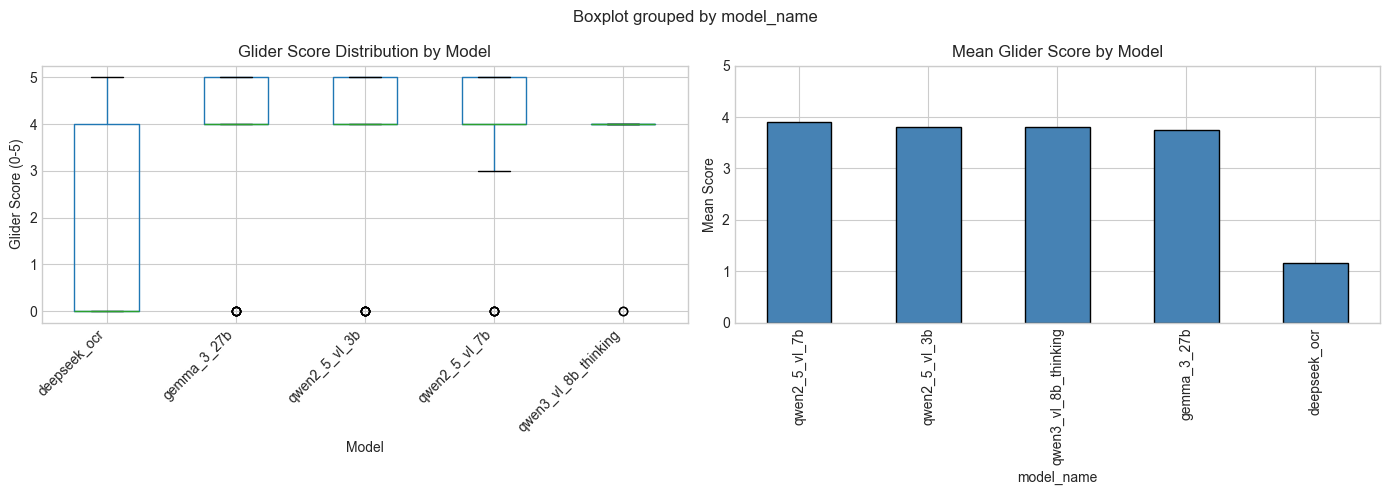

In [4]:
# Glider score distribution by model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df.boxplot(column='glider_score', by='model_name', ax=axes[0])
axes[0].set_title('Glider Score Distribution by Model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Glider Score (0-5)')
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right')

# Bar chart of mean scores
df.groupby('model_name')['glider_score'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Mean Glider Score by Model')
axes[1].set_ylabel('Mean Score')
axes[1].set_ylim(0, 5)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

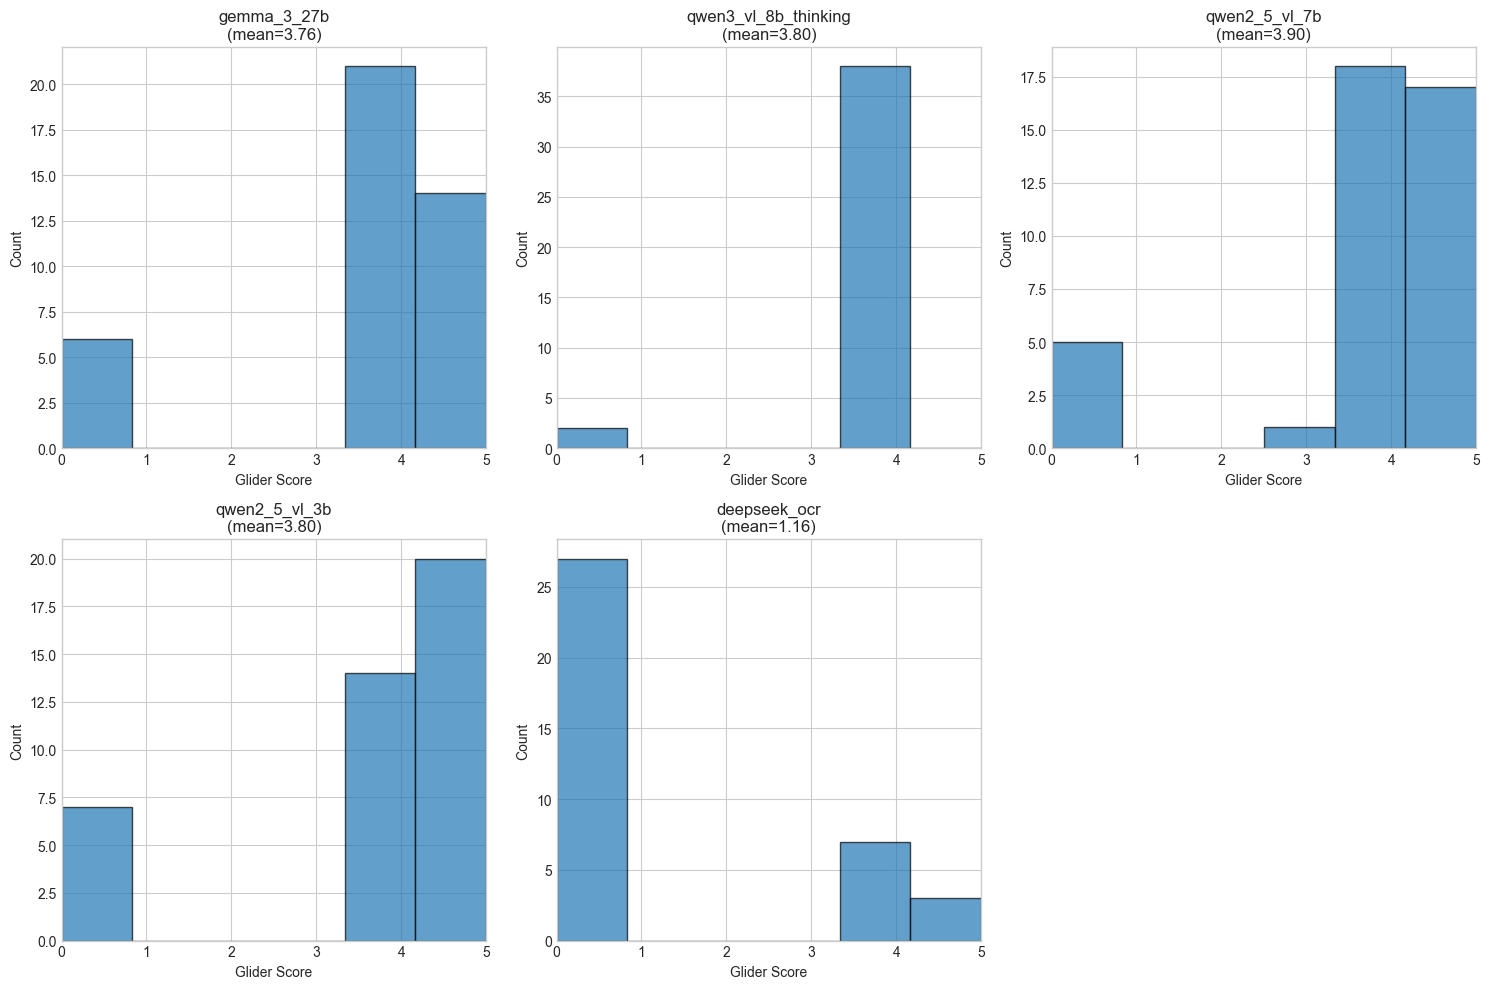

In [5]:
# Glider score histogram by model
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, model in enumerate(df['model_name'].unique()[:5]):
    model_data = df[df['model_name'] == model]['glider_score'].dropna()
    axes[idx].hist(model_data, bins=6, range=(0, 5), edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{model}\n(mean={model_data.mean():.2f})')
    axes[idx].set_xlabel('Glider Score')
    axes[idx].set_ylabel('Count')
    axes[idx].set_xlim(0, 5)

if len(axes) > 5:
    axes[5].axis('off')
plt.tight_layout()
plt.show()

## 3. Performance by Task

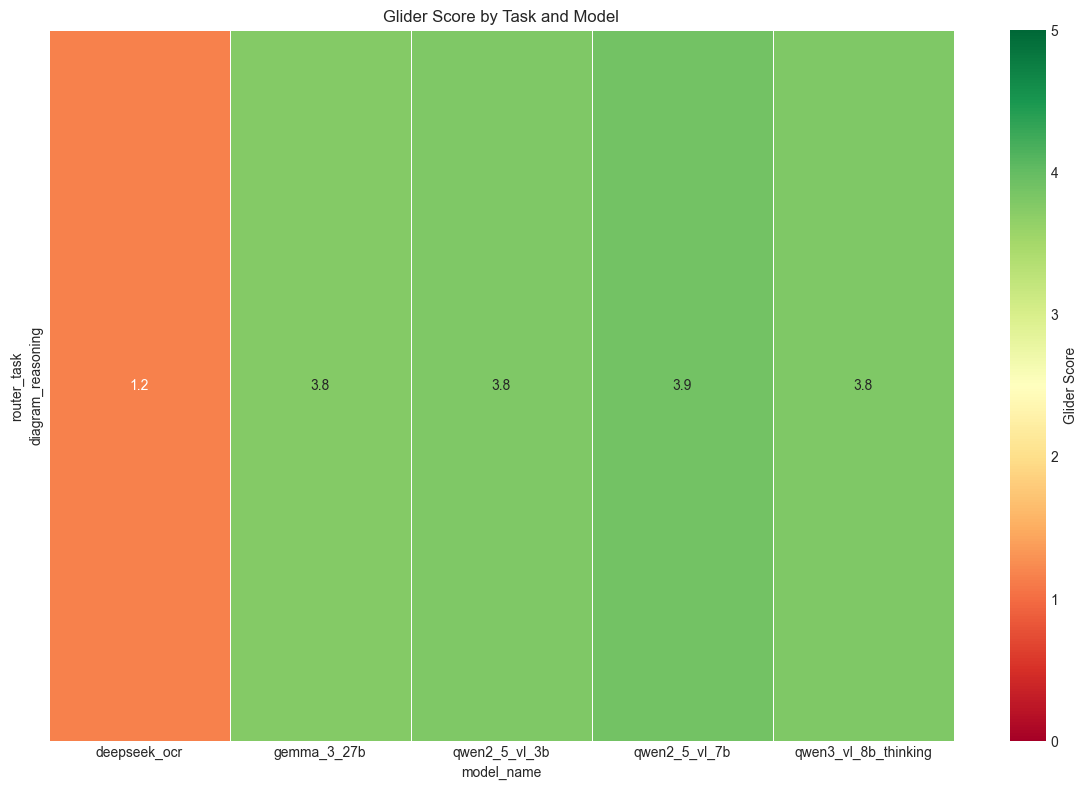

In [6]:
# Glider score by task and model
task_model = df.pivot_table(
    values='glider_score', 
    index='router_task', 
    columns='model_name', 
    aggfunc='mean'
).round(2)

plt.figure(figsize=(12, 8))
sns.heatmap(task_model, annot=True, cmap='RdYlGn', vmin=0, vmax=5, fmt='.1f', 
            linewidths=0.5, cbar_kws={'label': 'Glider Score'})
plt.title('Glider Score by Task and Model')
plt.tight_layout()
plt.show()

In [7]:
# Best model per task
best_per_task = task_model.idxmax(axis=1)
print('Best model per task:')
for task, model in best_per_task.items():
    score = task_model.loc[task, model]
    print(f'  {task}: {model} ({score:.2f})')

Best model per task:
  diagram_reasoning: qwen2_5_vl_7b (3.90)


## 4. Performance by Ground Truth Type

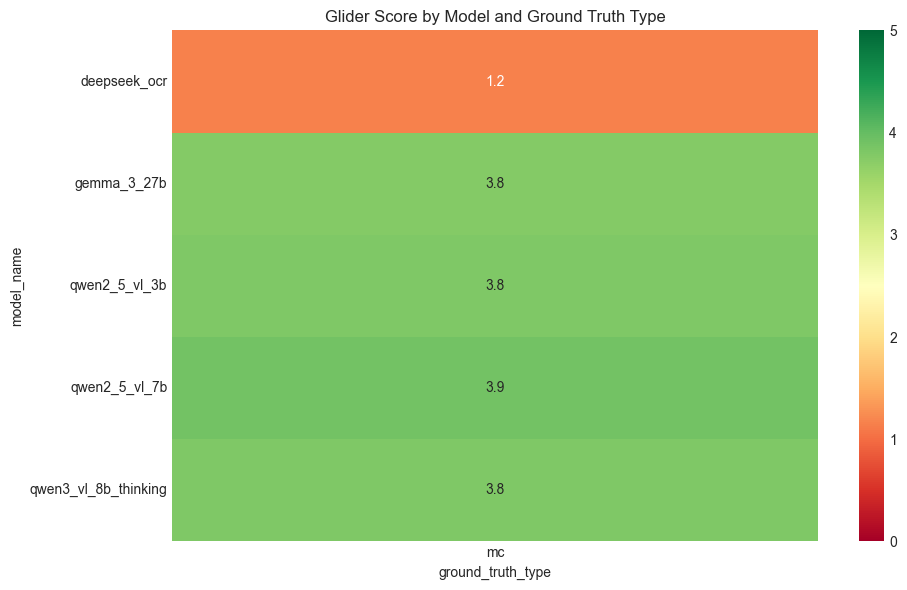

In [8]:
# By ground truth type
gt_pivot = df.pivot_table(
    values='glider_score', 
    index='model_name', 
    columns='ground_truth_type', 
    aggfunc='mean'
).round(2)

plt.figure(figsize=(10, 6))
sns.heatmap(gt_pivot, annot=True, cmap='RdYlGn', vmin=0, vmax=5, fmt='.1f')
plt.title('Glider Score by Model and Ground Truth Type')
plt.tight_layout()
plt.show()

## 5. Semantic F1 Analysis

In [9]:
# Semantic F1 summary (if available)
sem_df = df[df['semantic_f1_f1'].notna()]
if len(sem_df) > 0:
    sem_summary = sem_df.groupby('model_name').agg({
        'semantic_f1_precision': 'mean',
        'semantic_f1_recall': 'mean',
        'semantic_f1_f1': 'mean',
    }).round(3)
    sem_summary.columns = ['Precision', 'Recall', 'F1']
    print(f'Semantic F1 evaluated on {len(sem_df)} samples')
    display(sem_summary.sort_values('F1', ascending=False))
else:
    print('No Semantic F1 evaluations found. Run 02_evaluation_scoring with RUN_SEMANTIC_F1=True')

No Semantic F1 evaluations found. Run 02_evaluation_scoring with RUN_SEMANTIC_F1=True


## 6. Score Correlations

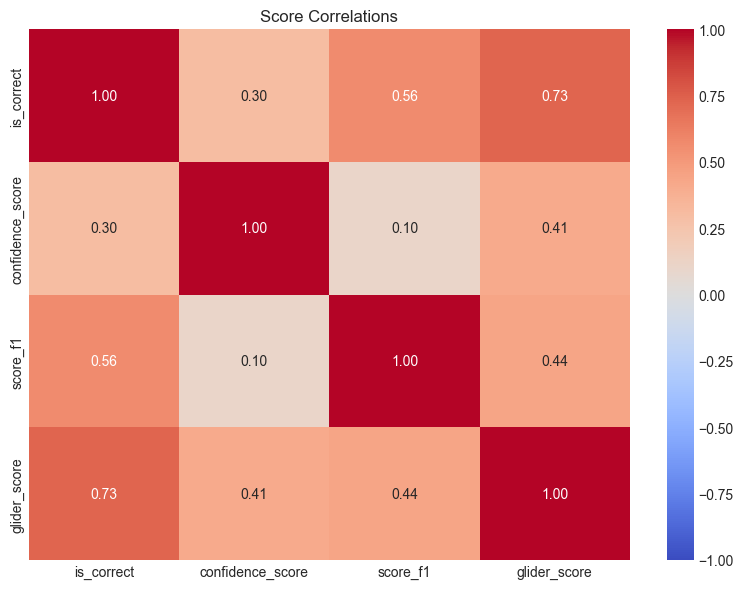

In [10]:
# Correlation between different metrics
score_cols = ['is_correct', 'confidence_score', 'score_f1', 'glider_score']
score_df = df[score_cols].dropna()

if len(score_df) > 10:
    corr = score_df.astype(float).corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
    plt.title('Score Correlations')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough data for correlation analysis')

## 7. Glider vs Confidence

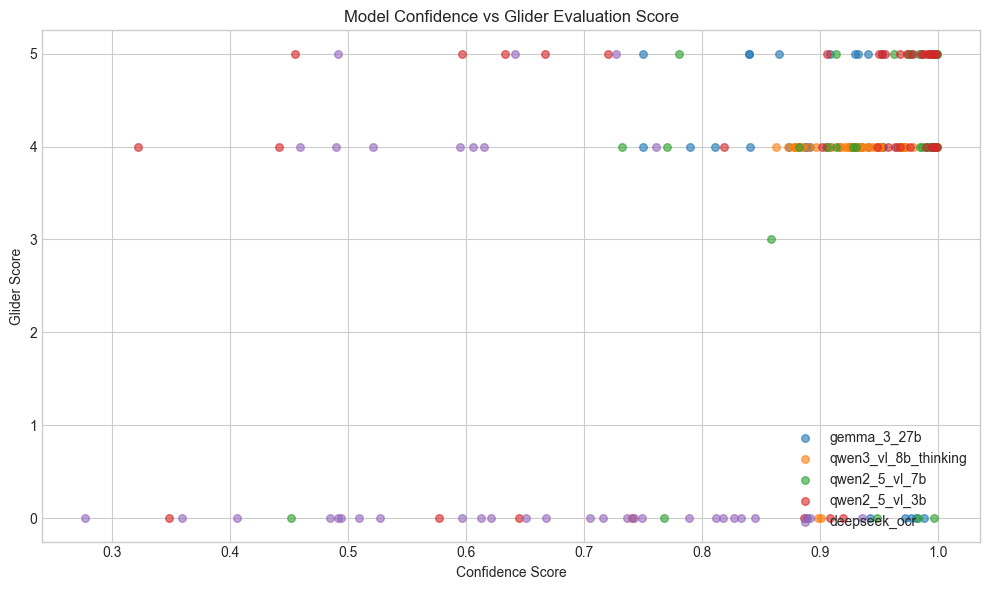

In [11]:
# Scatter: Glider score vs Confidence
plot_df = df[df['confidence_score'].notna() & df['glider_score'].notna()]

fig, ax = plt.subplots(figsize=(10, 6))
for model in plot_df['model_name'].unique():
    m_df = plot_df[plot_df['model_name'] == model]
    ax.scatter(m_df['confidence_score'], m_df['glider_score'], 
               label=model, alpha=0.6, s=30)

ax.set_xlabel('Confidence Score')
ax.set_ylabel('Glider Score')
ax.set_title('Model Confidence vs Glider Evaluation Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Sample Evaluation Reasoning

In [12]:
# View sample Glider reasoning
query = '''
SELECT e.sample_id, e.model_name, e.glider_score, 
       LEFT(e.glider_reasoning, 400) as reasoning,
       s.ground_truth, LEFT(r.response_raw, 200) as response
FROM vlm_evaluations e
JOIN vlm_samples s ON e.sample_id = s.sample_id
JOIN vlm_responses r ON e.sample_id = r.sample_id AND e.model_name = r.model_name
WHERE e.glider_reasoning IS NOT NULL
ORDER BY RANDOM()
LIMIT 3
'''
samples = pd.read_sql(query, engine)

for idx, row in samples.iterrows():
    print('='*70)
    print(f"Sample: {row['sample_id']} | Model: {row['model_name']} | Score: {row['glider_score']}/5")
    print(f"\nGround Truth: {row['ground_truth'][:100]}...")
    print(f"\nResponse: {row['response']}...")
    print(f"\nGlider Reasoning: {row['reasoning']}...")

Sample: ai2d_25_05a51952 | Model: qwen2_5_vl_7b | Score: 3.0/5

Ground Truth: Answer: D...

Response: D...

Glider Reasoning: - The model's output "D" matches the ground truth answer "Dashboard".
- There is a semantic inconsistency as the model's output does not match the expected answer "Dashboard".
- The model's output is semantically correct in terms of the label but does not align with the ground truth.
- The answer is concise and focused on the question, but the content is incorrect....
Sample: ai2d_38_ba8cfaf1 | Model: qwen3_vl_8b_thinking | Score: 4.0/5

Ground Truth: Answer: B...

Response: Got it, let's look at the diagram. The title says "FLY LIFE CYCLE". The stages shown are eggs, first-instar larva, second-instar larva, third-instar larva, pupa, and adult. So the question is asking w...

Glider Reasoning: - The model's answer is semantically correct and aligns with the ground truth, which is "B. Fly life cycle."
- The explanation provided by the model is mostly accurate, de

## 9. Summary Statistics

In [13]:
print('='*60)
print('EVALUATION SUMMARY')
print('='*60)
print(f'Total evaluations: {len(df):,}')
print(f'Unique samples: {df["sample_id"].nunique():,}')
print(f'Models: {df["model_name"].nunique()}')
print(f'Tasks: {df["router_task"].nunique()}')
print(f'\nOverall Glider Score: {df["glider_score"].mean():.2f}/5')
print(f'Overall Accuracy: {df["is_correct"].mean():.1%}')

print(f'\nModel Rankings (by Glider score):')
for i, (model, score) in enumerate(df.groupby('model_name')['glider_score'].mean().sort_values(ascending=False).items(), 1):
    print(f'  {i}. {model}: {score:.2f}')

EVALUATION SUMMARY
Total evaluations: 200
Unique samples: 41
Models: 5
Tasks: 1

Overall Glider Score: 3.33/5
Overall Accuracy: 61.5%

Model Rankings (by Glider score):
  1. qwen2_5_vl_7b: 3.90
  2. qwen2_5_vl_3b: 3.80
  3. qwen3_vl_8b_thinking: 3.80
  4. gemma_3_27b: 3.76
  5. deepseek_ocr: 1.16
